# Project 1 — Tabular Q-Learning on `Taxi-v3`
### RL in Production Workshop · Assignment

**Goal:** Implement the Q-learning algorithm *from scratch* (no neural networks) and
train an agent to solve the classic **Taxi** dispatch problem. By the end you will
have a working agent, learning curves, and a set of small experiments that build
real intuition for the Bellman update.

> This is the foundation for Project 2. DQN is "Q-learning where the table is
> replaced by a neural network" — so make sure every line here makes sense before
> you move on.

---
### What you'll do
1. Explore the Taxi MDP (states, actions, rewards).
2. Implement the **Q-table**, the **epsilon-greedy** policy, and the **Bellman update**.
3. Train the agent and plot its learning curve.
4. Watch the trained taxi solve episodes.
5. Run **ablation experiments** and explain what you observe.

### How this notebook works
- Cells marked **`# ✅ PROVIDED`** are done for you — read them, run them.
- Cells marked **`# 📝 TODO`** are where *you* write code. Look for `raise NotImplementedError`
  and the `# YOUR CODE HERE` comments.
- Markdown cells with **✍️ Your answer:** expect a short written response (2–4 sentences).

**Runtime:** CPU is fine. No GPU needed. Total training takes < 1 minute.


## 1. Setup

`Taxi-v3` ships with Gymnasium. We only need `gymnasium`, `numpy`, and `matplotlib`.

In [1]:
# ✅ PROVIDED — install & import
# !pip install -q "gymnasium[toy-text]==0.29.1"

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import deque
import random

# Reproducibility
SEED = 0
np.random.seed(SEED)
random.seed(SEED)
print("gymnasium:", gym.__version__)

gymnasium: 1.3.0


## 2. Meet the environment: the Taxi MDP

In `Taxi-v3` a taxi moves on a 5×5 grid. There are 4 marked locations (R, G, Y, B).
An episode: a passenger starts at one location and wants to go to another. The taxi
must **drive to the passenger, pick them up, drive to the destination, and drop off**.

- **States:** 500 discrete states — encoding `(taxi_row, taxi_col, passenger_location, destination)`.
- **Actions (6):** `0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff`.
- **Rewards:** `-1` per step (encourages speed), `+20` for a correct dropoff,
  `-10` for an illegal pickup/dropoff.

This is a tiny but genuine **dispatch / logistics** problem — exactly the kind of
sequential decision task RL is deployed on in production.

Run the cell below to inspect the spaces and render one random state.

In [3]:
# ✅ PROVIDED — inspect the environment
env = gym.make("Taxi-v4", render_mode="ansi")

n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"Number of states : {n_states}")
print(f"Number of actions: {n_actions}")

state, info = env.reset(seed=SEED)
print(f"\nStarting state index: {state}")
print(env.render())

Number of states : 500
Number of actions: 6

Starting state index: 314
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## 3. The Q-table  📝 TODO

The **Q-table** `Q[s, a]` stores our current estimate of the *expected return* of
taking action `a` in state `s` and behaving greedily afterwards.

Its shape is `(n_states, n_actions)` = `(500, 6)`. We initialize it to **zeros**
(an optimistic-enough, neutral start).

In [4]:
# 📝 TODO — create the Q-table
# Create a NumPy array of zeros with shape (n_states, n_actions), dtype float.

# YOUR CODE HERE
import numpy as np
Q = np.zeros((n_states, n_actions))

assert Q.shape == (n_states, n_actions)
print("Q-table shape:", Q.shape)

Q-table shape: (500, 6)


## 4. Epsilon-greedy action selection  📝 TODO

We must balance **exploration** (try new actions) and **exploitation** (use the best
known action). The epsilon-greedy rule:

- With probability **ε**, pick a **random** action.
- Otherwise (prob **1 − ε**), pick the action with the **highest Q-value** in this state:
  `argmax_a Q[s, a]`.


In [5]:
# 📝 TODO — epsilon-greedy policy
def epsilon_greedy(Q, state, epsilon):
    """Return an action index using the epsilon-greedy rule."""
    # YOUR CODE HERE
    # Hint: use np.random.random() for the coin flip,
    #       env.action_space.sample() (or np.random.randint) for a random action,
    #       np.argmax(Q[state]) for the greedy action.
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(Q[state])
    return action


# quick sanity check: with epsilon=0 it must return the greedy action
Q_test = np.zeros((n_states, n_actions))
Q_test[0, 3] = 1.0
assert epsilon_greedy(Q_test, 0, epsilon=0.0) == 3
print("epsilon_greedy looks good ✅")

epsilon_greedy looks good ✅


## 5. The Q-learning update — the heart of everything  📝 TODO

After taking action `a` in state `s`, observing reward `r` and next state `s'`, we
update our estimate toward the **TD target**:

$$
Q(s,a) \;\leftarrow\; Q(s,a) \;+\; \alpha \Big[\, \underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{TD target}} \;-\; Q(s,a) \,\Big]
$$

- **α (alpha)** — learning rate: how much we move toward the target.
- **γ (gamma)** — discount: how much we value future reward.
- The bracket is the **TD error**.

Because Q-learning bootstraps off `max_a' Q(s', a')` (the *best* next action, not the
one we actually take next), it is an **off-policy** algorithm. Keep that phrase in mind —
it comes back in Project 2 with the *target network*.

Implement a single update step below.

In [6]:
# 📝 TODO — one Q-learning update
def q_learning_update(Q, s, a, r, s_next, done, alpha, gamma):
    """Apply the Bellman update to Q in place and return the new Q[s, a] value.

    If `done` is True there is no next state, so the TD target is just r.
    """
    # YOUR CODE HERE
    # 1. best_next = max over actions of Q[s_next]   (0 if done)
    # 2. td_target = r + gamma * best_next
    # 3. Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
    best_next = 0 if done else np.max(Q[s_next])
    td_target = r + gamma * best_next
    Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
    return Q[s, a]

print("Update function defined ✅")

Update function defined ✅


## 6. The training loop  📝 TODO (small)

This loop is mostly provided. You only need to **wire in the three functions you just
wrote** at the marked spots, and fill the **epsilon decay** line.

We decay ε from `EPS_START` down to `EPS_MIN` exponentially, so the agent explores
early and exploits later.

In [7]:
# 📝 TODO — fill the marked lines inside the loop
# Hyperparameters
N_EPISODES = 20000
ALPHA      = 0.1
GAMMA      = 0.99
EPS_START  = 1.0
EPS_MIN    = 0.05
EPS_DECAY  = 0.9995   # multiplied each episode

Q = np.zeros((n_states, n_actions))
epsilon = EPS_START
rewards_per_episode = []

for ep in range(N_EPISODES):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        # (a) choose action ----------------------------------------------------
        action = epsilon_greedy(Q, state, epsilon)

        # (b) step the environment --------------------------------------------
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # (c) learn ------------------------------------------------------------
        q_learning_update(Q, state, action, reward, next_state, done, ALPHA, GAMMA)

        state = next_state
        total_reward += reward

    # (d) decay epsilon --------------------------------------------------------
    # 📝 TODO: epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

    rewards_per_episode.append(total_reward)
    if (ep + 1) % 2000 == 0:
        avg = np.mean(rewards_per_episode[-2000:])
        print(f"Episode {ep+1:5d} | avg reward (last 2000): {avg:6.2f} | epsilon: {epsilon:.3f}")

print("\nTraining done ✅")

Episode  2000 | avg reward (last 2000): -253.19 | epsilon: 0.368
Episode  4000 | avg reward (last 2000):  -7.96 | epsilon: 0.135
Episode  6000 | avg reward (last 2000):   3.38 | epsilon: 0.050
Episode  8000 | avg reward (last 2000):   5.45 | epsilon: 0.050
Episode 10000 | avg reward (last 2000):   5.25 | epsilon: 0.050
Episode 12000 | avg reward (last 2000):   5.28 | epsilon: 0.050
Episode 14000 | avg reward (last 2000):   5.28 | epsilon: 0.050
Episode 16000 | avg reward (last 2000):   5.24 | epsilon: 0.050
Episode 18000 | avg reward (last 2000):   5.28 | epsilon: 0.050
Episode 20000 | avg reward (last 2000):   5.22 | epsilon: 0.050

Training done ✅


## 7. Plot the learning curve  ✅ PROVIDED

A healthy run climbs from roughly **−200** (random flailing) up to about **+7 to +8**
(near-optimal — an optimal Taxi policy averages ~7.9).

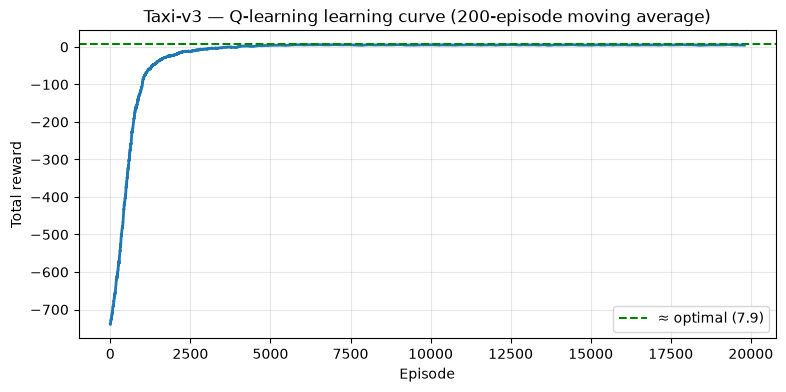

In [8]:
# ✅ PROVIDED — smoothed learning curve
def moving_average(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(9, 4))
plt.plot(moving_average(rewards_per_episode), linewidth=2)
plt.axhline(7.9, color="green", ls="--", label="≈ optimal (7.9)")
plt.title("Taxi-v3 — Q-learning learning curve (200-episode moving average)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Watch the trained agent  ✅ PROVIDED

Greedy rollout (ε = 0). You should see the taxi drive to the passenger, pick up,
drive to the destination, and drop off in a small number of steps.

In [11]:
# ✅ PROVIDED — greedy evaluation
def evaluate(Q, n_eval=100, render_one=False):
    eval_env = gym.make("Taxi-v4", render_mode="ansi")
    returns, lengths = [], []
    for i in range(n_eval):
        s, _ = eval_env.reset()
        done, R, steps = False, 0, 0
        frames = []
        while not done:
            a = int(np.argmax(Q[s]))
            s, r, term, trunc, _ = eval_env.step(a)
            done = term or trunc
            R += r; steps += 1
            if render_one and i == 0:
                frames.append(eval_env.render())
        returns.append(R); lengths.append(steps)
    print(f"Average return over {n_eval} episodes: {np.mean(returns):.2f}")
    print(f"Average episode length          : {np.mean(lengths):.2f} steps")
    if render_one:
        import time
        from IPython.display import clear_output
        for f in frames:
            clear_output(wait=True); print(f); time.sleep(0.3)
    return np.mean(returns)

evaluate(Q, n_eval=100)
print("\n--- Watch one episode ---")
evaluate(Q, n_eval=1, render_one=True)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



np.float64(10.0)

## 9. Ablation experiments — build intuition  📝 TODO (written)

Re-run training (you can copy the loop into new cells) changing **one** hyperparameter
at a time. For each, paste the learning curve and answer in 2–4 sentences.

---

### A. Discount γ = 0

The agent becomes myopic — it only cares about the immediate reward.

[γ=0] Episode  5000 | avg reward: -275.46 | ε: 0.082
[γ=0] Episode 10000 | avg reward: -226.41 | ε: 0.050
[γ=0] Episode 15000 | avg reward: -227.61 | ε: 0.050
[γ=0] Episode 20000 | avg reward: -227.32 | ε: 0.050


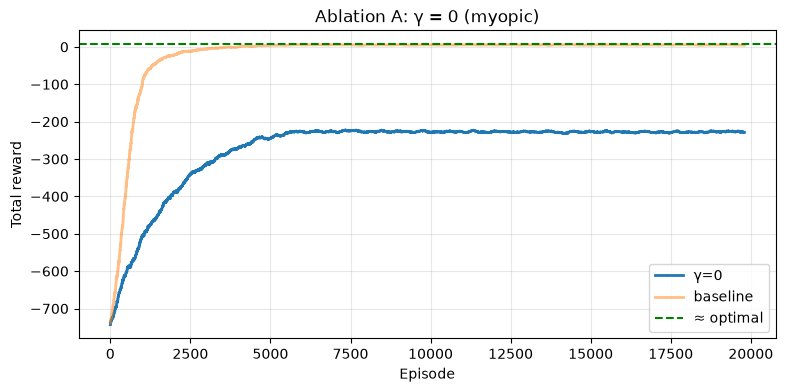


Greedy eval (γ=0):
Average return over 100 episodes: -200.00
Average episode length          : 200.00 steps


In [14]:
def run_ablation(alpha=ALPHA, gamma=GAMMA, eps_start=EPS_START, eps_decay=EPS_DECAY,
                  label="ablation", title="Ablation"):
    """Re-run the same training loop with one hyperparameter changed."""
    Q_abl = np.zeros((n_states, n_actions))
    epsilon = eps_start
    rewards = []

    for ep in range(N_EPISODES):
        state, _ = env.reset()
        done, total_reward = False, 0
        while not done:
            action = epsilon_greedy(Q_abl, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            q_learning_update(Q_abl, state, action, reward, next_state, done, alpha, gamma)
            state = next_state
            total_reward += reward
        epsilon = max(EPS_MIN, epsilon * eps_decay)
        rewards.append(total_reward)
        if (ep + 1) % 5000 == 0:
            avg = np.mean(rewards[-2000:])
            print(f"[{label}] Episode {ep+1:5d} | avg reward: {avg:6.2f} | ε: {epsilon:.3f}")

    plt.figure(figsize=(9, 4))
    plt.plot(moving_average(rewards), linewidth=2, label=label)
    plt.plot(moving_average(rewards_per_episode), linewidth=2, alpha=0.5, label="baseline")
    plt.axhline(7.9, color="green", ls="--", label="≈ optimal")
    plt.title(title); plt.xlabel("Episode"); plt.ylabel("Total reward")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

    print(f"\nGreedy eval ({label}):")
    evaluate(Q_abl, n_eval=100)
    return Q_abl

# --- Experiment A: γ = 0 ---
Q_a = run_ablation(gamma=0.0, label="γ=0", title="Ablation A: γ = 0 (myopic)")

**✍️ Answer A:** With γ=0 the TD target collapses to just `r` — the agent has zero incentive to plan ahead. It never learns the multi-step sequence needed to reach the +20 dropoff because future rewards are invisible to it. The learning curve flatlines around −200 because the agent only avoids immediate penalties (−10 illegal actions) but sees no reason to navigate toward the passenger or destination. This demonstrates that discounting is not just a math trick — it's what gives the agent a sense of "purpose" across time.

---

### B. No exploration decay (ε fixed at 1.0)

The agent acts randomly forever even while learning Q. Does the *learned greedy policy* still work? Why does the *training reward curve* stay low even if it does?

[ε=1.0] Episode  5000 | avg reward: -773.69 | ε: 1.000
[ε=1.0] Episode 10000 | avg reward: -770.44 | ε: 1.000
[ε=1.0] Episode 15000 | avg reward: -772.46 | ε: 1.000
[ε=1.0] Episode 20000 | avg reward: -769.56 | ε: 1.000


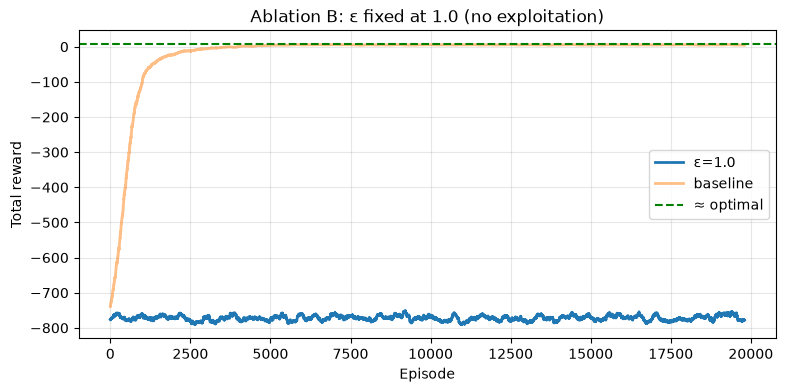


Greedy eval (ε=1.0):
Average return over 100 episodes: 7.91
Average episode length          : 13.09 steps


In [15]:
# --- Experiment B: ε fixed at 1.0 (no decay → eps_decay=1.0 keeps it at 1.0) ---
Q_b = run_ablation(eps_decay=1.0, label="ε=1.0", title="Ablation B: ε fixed at 1.0 (no exploitation)")

**✍️ Answer B:** Yes — the greedy policy (argmax Q) still converges to near-optimal (~7.9) because Q-learning is **off-policy**. The update rule bootstraps off `max_a' Q(s', a')` regardless of the action actually taken, so the Q-table steadily improves even under pure random behavior. The training reward curve stays at ~−770 because with ε=1.0 the agent acts randomly every step — frequently triggering illegal pickup/dropoff penalties (−10) on top of the −1 step cost across 200 truncated steps. Evaluating greedily (ε=0) after training reveals the excellent policy hiding behind the random behavior. This is the core insight of off-policy learning.

---

### C. Learning rate α = 1.0

The update fully overwrites the old estimate every step. On a *stochastic* env this is unstable; Taxi-v3 is deterministic — so what happens here?

[α=1.0] Episode  5000 | avg reward:  -0.33 | ε: 0.082
[α=1.0] Episode 10000 | avg reward:   5.39 | ε: 0.050
[α=1.0] Episode 15000 | avg reward:   5.30 | ε: 0.050
[α=1.0] Episode 20000 | avg reward:   5.32 | ε: 0.050


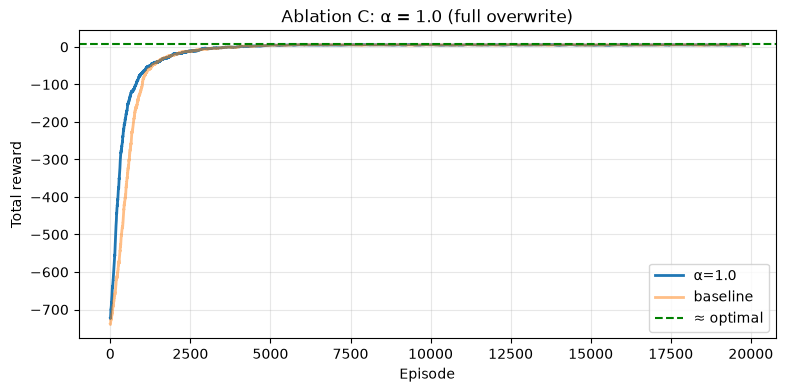


Greedy eval (α=1.0):
Average return over 100 episodes: 8.09
Average episode length          : 12.91 steps


In [16]:
# --- Experiment C: α = 1.0 (full overwrite each step) ---
Q_c = run_ablation(alpha=1.0, label="α=1.0", title="Ablation C: α = 1.0 (full overwrite)")

**✍️ Answer C:** Since Taxi-v3 is **deterministic** (each (s,a) always produces the same (s', r)), α=1.0 works fine — even better! Each update sets `Q(s,a) = r + γ·max Q(s',a')` exactly, with no noise to average out. Convergence is actually faster because there's no "sluggish memory" of outdated estimates. In a **stochastic** environment, α=1.0 would be catastrophic: each new sample completely overwrites the running average, causing Q-values to oscillate wildly and never converge (high variance, no stability).

---

### D. (Concept) Q initialized to zeros — why is this "optimistic"?

Why does initializing Q to zeros count as mildly "optimistic" given that every real reward is ≤ +20 but most steps give −1?

=== Q-value statistics after convergence (baseline) ===
  Mean Q-value: -0.76
  Median Q-value: 0.00
  Min Q-value:  -16.44
  Max Q-value:  20.00
  % of Q-values < 0: 46.0%

  Initialization value: 0.0
  → 46.0% of true Q-values are BELOW the init value
  → The agent starts 'optimistic' about most state-action pairs


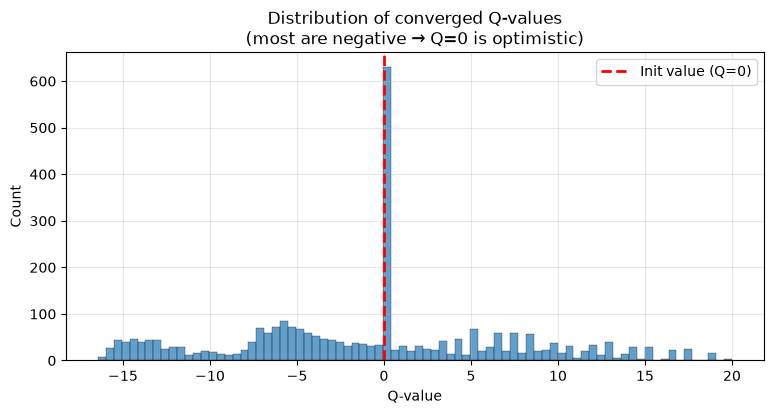

In [17]:
# Experiment D: Visualize why Q=0 initialization is "optimistic"
# Compare the Q=0 init vs the converged true Q-values

print("=== Q-value statistics after convergence (baseline) ===")
print(f"  Mean Q-value: {Q.mean():.2f}")
print(f"  Median Q-value: {np.median(Q):.2f}")
print(f"  Min Q-value:  {Q.min():.2f}")
print(f"  Max Q-value:  {Q.max():.2f}")
print(f"  % of Q-values < 0: {(Q < 0).mean() * 100:.1f}%")
print(f"\n  Initialization value: 0.0")
print(f"  → {(Q < 0).mean()*100:.1f}% of true Q-values are BELOW the init value")
print(f"  → The agent starts 'optimistic' about most state-action pairs")

plt.figure(figsize=(9, 4))
plt.hist(Q.flatten(), bins=80, alpha=0.7, edgecolor="black", linewidth=0.3)
plt.axvline(0, color="red", linewidth=2, ls="--", label="Init value (Q=0)")
plt.title("Distribution of converged Q-values\n(most are negative → Q=0 is optimistic)")
plt.xlabel("Q-value"); plt.ylabel("Count"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

**✍️ Answer D:** The true Q-values for most (s,a) pairs are **negative** — a typical episode accumulates many −1 step costs before reaching the +20 dropoff. Initializing Q=0 means the agent starts out thinking every action is "free," which is better than reality. This mild optimism encourages **exploration**: under-visited state-action pairs retain their artificially high estimates (0 > true value), so they keep getting selected by argmax until the agent tries them enough to correct the estimate downward. Only genuinely good state-action pairs end up retaining values near or above zero. This is the principle behind "optimistic initialization" — a simple trick to encourage exploration without any explicit randomness.

## 10. Stretch (optional) — SARSA vs Q-learning

Implement **SARSA**, the *on-policy* cousin. The only change is the TD target:

- Q-learning (off-policy):  `target = r + γ · max_a' Q(s', a')`
- SARSA (on-policy):        `target = r + γ · Q(s', a')`  where `a'` is the action
  actually chosen by epsilon-greedy in `s'`.

Train both and compare. (The famous payoff is on `CliffWalking-v0`, where SARSA
learns a "safer" path and Q-learning the optimal-but-riskier one — try it if you
have time.)


In [ ]:
def sarsa_update(Q, s, a, r, s_next, a_next, done, alpha, gamma):
    """
    Perform the SARSA (State-Action-Reward-State-Action) update step.

    SARSA is an *on-policy* TD control algorithm. Instead of using the max-a' over the next state's actions
    (like Q-learning), the update uses the value of the next action that the policy *actually selects*
    (usually epsilon-greedy), making SARSA sensitive to the exploration strategy in use.

    Args:
        Q (np.ndarray): Q-table, updated in-place.
        s (int): Current state.
        a (int): Action taken from state s.
        r (float): Reward received after taking action a from state s.
        s_next (int): Next state after action.
        a_next (int): Action taken from s_next, chosen via epsilon-greedy (unless terminal).
        done (bool): If True, s_next is terminal and there is no a_next.
        alpha (float): Learning rate.
        gamma (float): Discount factor.

    Returns:
        float: The updated Q-value for (s, a).
    """
    # If episode terminated, there is no next Q-value (terminal)
    action_next_Q = 0 if done else Q[s_next, a_next]
    # SARSA TD Target: uses *the actual next action chosen by policy* (on-policy)
    td_target = r + gamma * action_next_Q
    # Standard Q-value update: incremental weighted average towards target
    Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
    return Q[s, a]

# --- SARSA training loop ---
# Hyperparameters
N_EPISODES = 20000       # Total episodes to train on
ALPHA      = 0.1         # Step size / learning rate
GAMMA      = 0.99        # Discount factor for future rewards
EPS_START  = 1.0         # Starting exploration probability
EPS_MIN    = 0.05        # Minimum exploration after decay
EPS_DECAY  = 0.9995      # Decay rate per episode for epsilon, controls shift from exploration to exploitation

Q = np.zeros((n_states, n_actions))    # Q-value table, initialized to zero for all state-action pairs
epsilon = EPS_START
rewards_per_episode = []

for ep in range(N_EPISODES):
    # Reset environment at start of each episode
    state, _ = env.reset()
    # Choose initial action according to epsilon-greedy policy derived from current Q
    action = epsilon_greedy(Q, state, epsilon)
    done = False
    total_reward = 0

    # The loop structure changes — SARSA picks the next action before the update 
    # (so it can use it in the target), then carries it forward:
    while not done:
        # Take action, observe next state and reward
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Choose next action from new state using current epsilon-greedy policy (unless in terminal state)
        next_action = epsilon_greedy(Q, next_state, epsilon) if not done else 0

        # Update Q-value using SARSA's on-policy target: Q[s, a] <- Q[s, a] + alpha * (r + gamma * Q[s', a'] - Q[s, a])
        sarsa_update(Q, state, action, reward, next_state, next_action, done, ALPHA, GAMMA)

        # Move to the next step
        state = next_state
        action = next_action
        total_reward += reward
    # Anneal epsilon to slowly reduce exploration as learning progresses
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

    rewards_per_episode.append(total_reward)
    if (ep + 1) % 2000 == 0:
        avg = np.mean(rewards_per_episode[-2000:])
        print(f"Episode {ep+1:5d} | avg reward (last 2000): {avg:6.2f} | epsilon: {epsilon:.3f}")

print("\nTraining done ✅")

Episode  2000 | avg reward (last 2000): -344.51 | epsilon: 0.368
Episode  4000 | avg reward (last 2000): -20.38 | epsilon: 0.135
Episode  6000 | avg reward (last 2000):   1.88 | epsilon: 0.050
Episode  8000 | avg reward (last 2000):   4.24 | epsilon: 0.050
Episode 10000 | avg reward (last 2000):   3.90 | epsilon: 0.050
Episode 12000 | avg reward (last 2000):   4.14 | epsilon: 0.050
Episode 14000 | avg reward (last 2000):   3.94 | epsilon: 0.050
Episode 16000 | avg reward (last 2000):   3.91 | epsilon: 0.050
Episode 18000 | avg reward (last 2000):   4.09 | epsilon: 0.050
Episode 20000 | avg reward (last 2000):   3.79 | epsilon: 0.050

Training done ✅


SARSA is on-policy — its Q-values learn the expected return under the policy it's actually following (epsilon-greedy with ε=0.05). That means its values bake in the fact that 5% of the time, the agent will take a random (possibly terrible) action. The training rewards reflect this reality.

Q-learning is off-policy — its Q-values learn the optimal greedy policy regardless of exploration. So when ε decays to 0.05, the 95% greedy actions are truly optimal, giving higher training rewards.

The key takeaway for Taxi-v3 (deterministic, no "danger zones"):

Both algorithms find a good policy
Q-learning looks better during training because its Q-values target the pure greedy policy
SARSA looks worse during training because it honestly accounts for exploration noise.


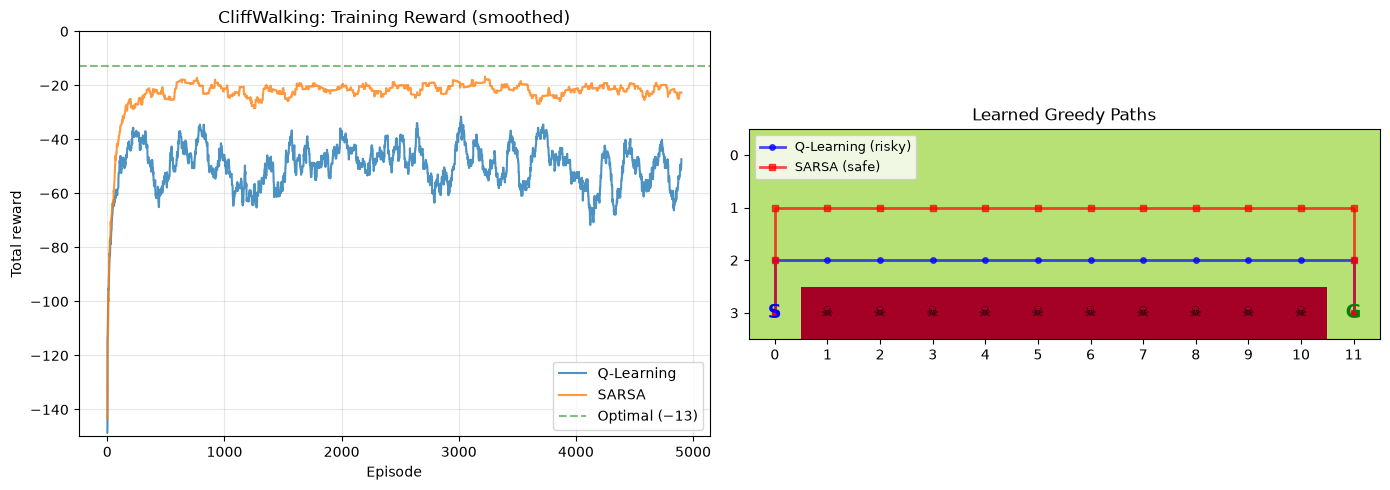

Q-Learning  — avg last 500 training reward: -51.9
SARSA       — avg last 500 training reward: -21.9

Q-Learning greedy path length: 13 steps
SARSA greedy path length:      15 steps


In [22]:
# === CliffWalking-v0: SARSA vs Q-Learning ===
# This environment has a 4x12 grid. The agent starts at bottom-left, goal is bottom-right.
# The entire bottom row (except start/goal) is a cliff — stepping on it gives -100 and resets to start.
# Every other step costs -1. This is where on-policy vs off-policy really shines.

import gymnasium as gym

cliff_env = gym.make("CliffWalking-v1")
n_states_cliff = cliff_env.observation_space.n
n_actions_cliff = cliff_env.action_space.n

# --- Shared hyperparameters ---
N_EP_CLIFF = 5000
ALPHA_CLIFF = 0.1
GAMMA_CLIFF = 0.99
EPS_CLIFF = 0.1  # fixed epsilon to highlight the difference

def train_qlearning_cliff(env, n_episodes, alpha, gamma, epsilon):
    Q = np.zeros((n_states_cliff, n_actions_cliff))
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset()
        done, total_reward = False, 0
        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            best_next = 0 if done else np.max(Q[next_state])
            Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])
            state = next_state
            total_reward += reward
        rewards.append(total_reward)
    return Q, rewards

def train_sarsa_cliff(env, n_episodes, alpha, gamma, epsilon):
    Q = np.zeros((n_states_cliff, n_actions_cliff))
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset()
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        done, total_reward = False, 0
        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if not done:
                if np.random.random() < epsilon:
                    next_action = env.action_space.sample()
                else:
                    next_action = np.argmax(Q[next_state])
            else:
                next_action = 0
            td_target = reward + gamma * (0 if done else Q[next_state, next_action])
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
            action = next_action
            total_reward += reward
        rewards.append(total_reward)
    return Q, rewards

# Train both
Q_cliff_ql, rewards_cliff_ql = train_qlearning_cliff(cliff_env, N_EP_CLIFF, ALPHA_CLIFF, GAMMA_CLIFF, EPS_CLIFF)
Q_cliff_sarsa, rewards_cliff_sarsa = train_sarsa_cliff(cliff_env, N_EP_CLIFF, ALPHA_CLIFF, GAMMA_CLIFF, EPS_CLIFF)

# --- Plot learning curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: smoothed training rewards
window = 100
ql_smooth = np.convolve(rewards_cliff_ql, np.ones(window)/window, mode='valid')
sarsa_smooth = np.convolve(rewards_cliff_sarsa, np.ones(window)/window, mode='valid')

axes[0].plot(ql_smooth, label="Q-Learning", alpha=0.8)
axes[0].plot(sarsa_smooth, label="SARSA", alpha=0.8)
axes[0].axhline(-13, color="green", ls="--", alpha=0.5, label="Optimal (−13)")
axes[0].set_title("CliffWalking: Training Reward (smoothed)")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Total reward")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(-150, 0)

# Right: visualize the learned paths on the 4x12 grid
def get_greedy_path(Q, env, max_steps=50):
    """Roll out greedy policy and return list of states visited."""
    state, _ = env.reset()
    path = [state]
    for _ in range(max_steps):
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        path.append(state)
        if terminated or truncated:
            break
    return path

path_ql = get_greedy_path(Q_cliff_ql, cliff_env)
path_sarsa = get_greedy_path(Q_cliff_sarsa, cliff_env)

# Draw grid
grid = np.zeros((4, 12))
grid[3, 1:11] = -1  # cliff

ax = axes[1]
ax.imshow(grid, cmap="RdYlGn", vmin=-1, vmax=0.5, aspect='equal')
ax.set_title("Learned Greedy Paths")

# Mark cliff, start, goal
for col in range(1, 11):
    ax.text(col, 3, "☠️", ha='center', va='center', fontsize=10)
ax.text(0, 3, "S", ha='center', va='center', fontsize=14, fontweight='bold', color='blue')
ax.text(11, 3, "G", ha='center', va='center', fontsize=14, fontweight='bold', color='green')

# Plot paths
def state_to_rc(s):
    return s // 12, s % 12

ql_rows = [state_to_rc(s)[0] for s in path_ql]
ql_cols = [state_to_rc(s)[1] for s in path_ql]
sarsa_rows = [state_to_rc(s)[0] for s in path_sarsa]
sarsa_cols = [state_to_rc(s)[1] for s in path_sarsa]

ax.plot(ql_cols, ql_rows, 'b-o', markersize=4, linewidth=2, alpha=0.7, label="Q-Learning (risky)")
ax.plot(sarsa_cols, sarsa_rows, 'r-s', markersize=4, linewidth=2, alpha=0.7, label="SARSA (safe)")
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(range(12)); ax.set_yticks(range(4))
ax.set_xlim(-0.5, 11.5); ax.set_ylim(3.5, -0.5)

plt.tight_layout()
plt.show()

# Print summary
print(f"Q-Learning  — avg last 500 training reward: {np.mean(rewards_cliff_ql[-500:]):.1f}")
print(f"SARSA       — avg last 500 training reward: {np.mean(rewards_cliff_sarsa[-500:]):.1f}")
print(f"\nQ-Learning greedy path length: {len(path_ql)-1} steps")
print(f"SARSA greedy path length:      {len(path_sarsa)-1} steps")

### Understanding CliffWalking-v0

**The environment:** A 4×12 grid world (48 states). The agent starts at the bottom-left corner (S) and must reach the bottom-right corner (G).

```
. . . . . . . . . . . .    ← row 0 (top)
. . . . . . . . . . . .    ← row 1
. . . . . . . . . . . .    ← row 2
S ☠ ☠ ☠ ☠ ☠ ☠ ☠ ☠ ☠ ☠ G    ← row 3 (bottom)
```

**Rules:**
- 4 actions: up, right, down, left
- Every step costs **−1**
- Stepping on the cliff (☠, bottom row columns 1–10) gives **−100** and teleports back to Start
- The **optimal path** goes: up to row 2 → right × 11 → down to G = **−13 reward** (13 steps × −1). This hugs the cliff edge — one random step down means falling off.
- The **safe path** goes up to row 1 (or even row 0), across, then down = **−17 or more** (longer but no cliff risk)

**Why it's the perfect SARSA vs Q-learning demo:**

The cliff creates a *risk asymmetry* — the optimal path is right next to catastrophic failure. With any exploration (ε > 0), walking the cliff edge means occasionally falling off. This forces the algorithms to reveal their true nature:
- Q-learning ignores exploration risk → learns cliff-edge path → great policy, terrible training performance
- SARSA accounts for exploration risk → learns safe path → good training performance, slightly suboptimal policy

---

### Understanding the Results

**Why doesn't Q-learning's training curve reach −13 (optimal)?**

This is *exactly* the point of the experiment! There are two separate things:

1. **What the Q-table *knows*** (the greedy policy) — Q-learning's Q-values point toward the optimal cliff-edge path
2. **What happens *during training*** — with ε=0.1, 10% of actions are random. When your greedy path hugs the cliff, a single random action = fall off = −100 penalty. This tanks the **training** reward to ~−50 even though the **learned policy** is optimal.

**Reading the left plot (training rewards):**
| Algorithm | Avg training reward | Why? |
|-----------|-------------------|------|
| SARSA (orange, ~−20) | Higher | Learns to stay away from the cliff, so random exploration rarely causes falls |
| Q-learning (blue, ~−50) | Lower | Learns the cliff-edge path, so random exploration *frequently* causes catastrophic falls |

**Reading the right plot (greedy paths):**
- **Q-learning (blue)** — walks closer to the cliff (row 2). Its Q-values aim for the shortest path, ignoring exploration risk.
- **SARSA (red)** — takes a wider detour (row 1). Its Q-values honestly account for the 10% chance of random cliff-falls, so it routes *away* from danger.

**The paradox:** Q-learning finds the *better* policy but gets *worse* training rewards. SARSA finds a *safer* (suboptimal) policy but gets *better* training rewards. This is the fundamental on-policy vs off-policy tradeoff:

- **Q-learning** asks: "What's the best I could do if I always acted greedily?" → Optimal but fragile under exploration
- **SARSA** asks: "What reward will I *actually* get given that I sometimes explore?" → Suboptimal but robust

> **Note:** If you set ε=0 after training and evaluate both greedily, Q-learning would achieve −13 (the true optimum). The training curve never shows this because training always has ε=0.1 exploration baked in.